# ML Experiment Leaderboard: Used Car Price Prediction

| Metadata | Value |
|---|---|
| **Date Generated** | 2025-03-13 |
| **Total Runs** | 8 |
| **Best Model** | LightGBM (Run 8) - R² = 0.930 |
| **Dataset** | Used Car Prices |

This notebook summarizes all tracked experiments for the used car price prediction task,
generated automatically by the experiment-tracker skill.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display, HTML

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# Color palette for models
MODEL_COLORS = {
    'LinearRegression': '#636EFA',
    'Ridge': '#EF553B',
    'RandomForest': '#00CC96',
    'GradientBoosting': '#AB63FA',
    'XGBoost': '#FFA15A',
    'LightGBM': '#19D3F3',
}

print('Setup complete.')

Setup complete.


In [2]:
# Load tracker data
with open('../experiments/tracker.json', 'r') as f:
    runs = json.load(f)

# Flatten into a DataFrame
records = []
for run in runs:
    record = {
        'Run': run['run_id'],
        'Timestamp': run['timestamp'],
        'Model': run['model'],
        'MAE': run['metrics']['mae'],
        'RMSE': run['metrics']['rmse'],
        'R\u00b2': run['metrics']['r2'],
        'Training Time (s)': run['metrics']['training_time_s'],
        'Notes': run['notes'],
    }
    records.append(record)

df = pd.DataFrame(records)

# Sort by R\u00b2 descending for leaderboard view
leaderboard = df.sort_values('R\u00b2', ascending=False).reset_index(drop=True)
leaderboard.index = leaderboard.index + 1  # 1-based rank
leaderboard.index.name = 'Rank'

# Style the DataFrame
styled = (
    leaderboard[['Run', 'Model', 'R\u00b2', 'MAE', 'RMSE', 'Training Time (s)', 'Notes']]
    .style
    .background_gradient(subset=['R\u00b2'], cmap='Greens')
    .background_gradient(subset=['MAE'], cmap='Reds_r')
    .background_gradient(subset=['RMSE'], cmap='Reds_r')
    .format({
        'R\u00b2': '{:.3f}',
        'MAE': '${:,.2f}',
        'RMSE': '${:,.2f}',
        'Training Time (s)': '{:.1f}s',
    })
    .set_caption('Experiment Leaderboard (sorted by R\u00b2 descending)')
)
display(styled)

,Run,Model,R²,MAE,RMSE,Training Time (s),Notes
Rank,,,,,,,
1,8,LightGBM,0.930,"$1,534.67","$2,245.10",15.2s,Final LightGBM. Lower LR + more trees + target encoding for brand. Best overall. R2=0.93.
2,7,LightGBM,0.926,"$1,578.21","$2,298.45",8.9s,LightGBM with same feature pipeline as XGBoost. Slightly better and 2.5x faster training.
3,6,XGBoost,0.923,"$1,612.34","$2,345.88",22.1s,XGBoost with regularization. Added log-transform on price target. Best so far.
4,5,GradientBoosting,0.899,"$1,845.90","$2,690.12",34.7s,sklearn GBR. Strong results. Same feature set as run 4.
5,4,RandomForest,0.885,"$1,987.42","$2,876.31",58.3s,Tuned RF. More trees + depth cap reduces overfitting. Added mileage_per_year feature.
6,3,RandomForest,0.866,"$2,156.78","$3,102.55",12.4s,Default RF. Big jump in performance. Added one-hot encoding for brand and fuel_type.
7,2,Ridge,0.631,"$3,798.33","$5,145.20",1.1s,Ridge with default alpha. Slight improvement over baseline.
8,1,LinearRegression,0.621,"$3,842.15","$5,210.44",0.8s,Baseline model on raw features. No feature engineering.


## Performance Summary

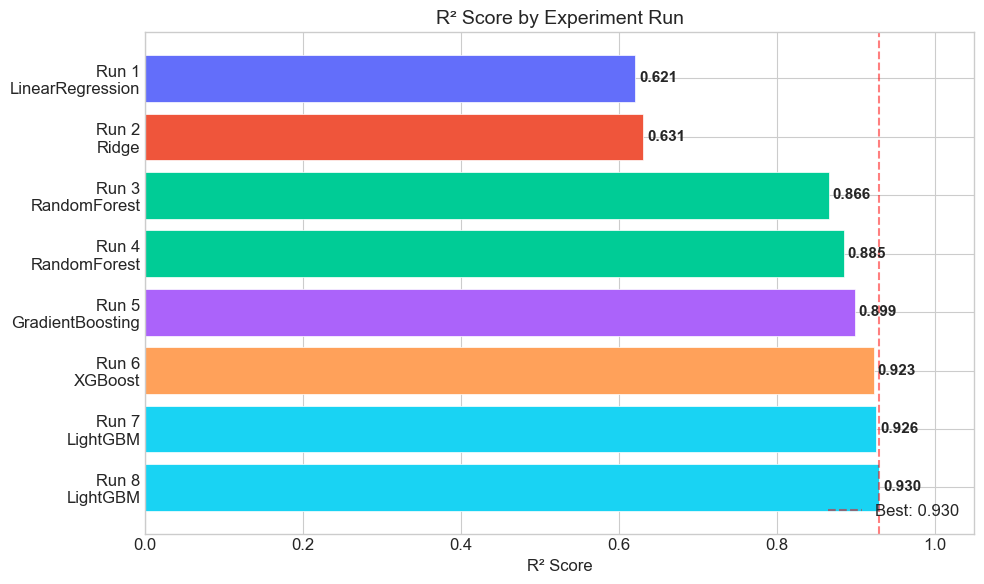

In [3]:
# Bar chart: R\u00b2 scores across all runs
fig, ax = plt.subplots(figsize=(10, 6))

labels = [f"Run {row['Run']}\n{row['Model']}" for _, row in df.iterrows()]
colors = [MODEL_COLORS.get(row['Model'], '#999999') for _, row in df.iterrows()]
r2_values = df['R\u00b2'].values

bars = ax.barh(labels, r2_values, color=colors, edgecolor='white', linewidth=0.5)

# Add value labels on bars
for bar, val in zip(bars, r2_values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('R\u00b2 Score')
ax.set_title('R\u00b2 Score by Experiment Run')
ax.set_xlim(0, 1.05)
ax.invert_yaxis()  # Best at top

# Add a vertical reference line at best score
ax.axvline(x=r2_values.max(), color='red', linestyle='--', alpha=0.5, label=f'Best: {r2_values.max():.3f}')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

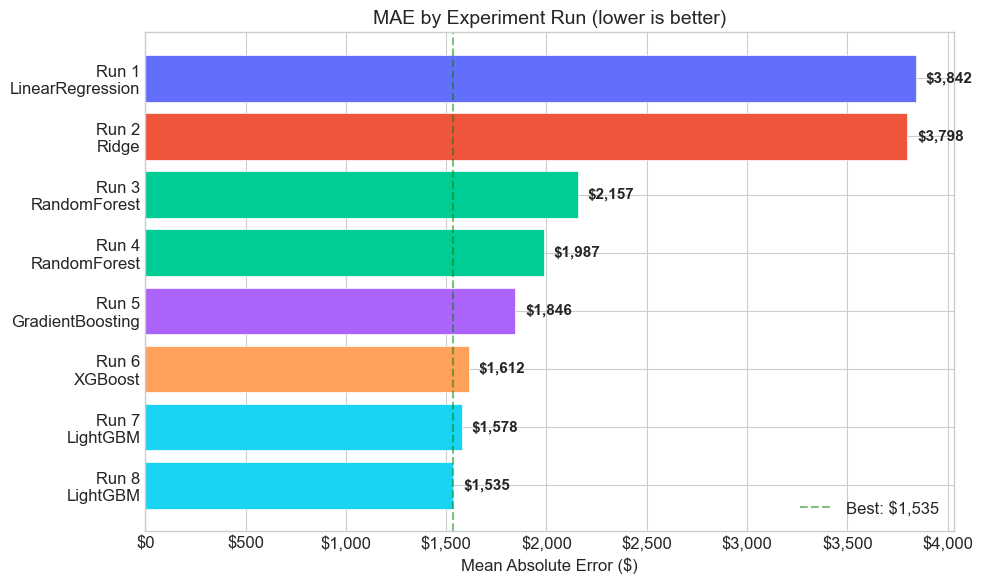

In [4]:
# Bar chart: MAE across all runs
fig, ax = plt.subplots(figsize=(10, 6))

labels = [f"Run {row['Run']}\n{row['Model']}" for _, row in df.iterrows()]
colors = [MODEL_COLORS.get(row['Model'], '#999999') for _, row in df.iterrows()]
mae_values = df['MAE'].values

bars = ax.barh(labels, mae_values, color=colors, edgecolor='white', linewidth=0.5)

# Add value labels on bars
for bar, val in zip(bars, mae_values):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
            f'${val:,.0f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Mean Absolute Error ($)')
ax.set_title('MAE by Experiment Run (lower is better)')
ax.invert_yaxis()

# Add a vertical reference line at best (lowest) MAE
ax.axvline(x=mae_values.min(), color='green', linestyle='--', alpha=0.5, label=f'Best: ${mae_values.min():,.0f}')
ax.legend(loc='lower right')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

## Training Efficiency

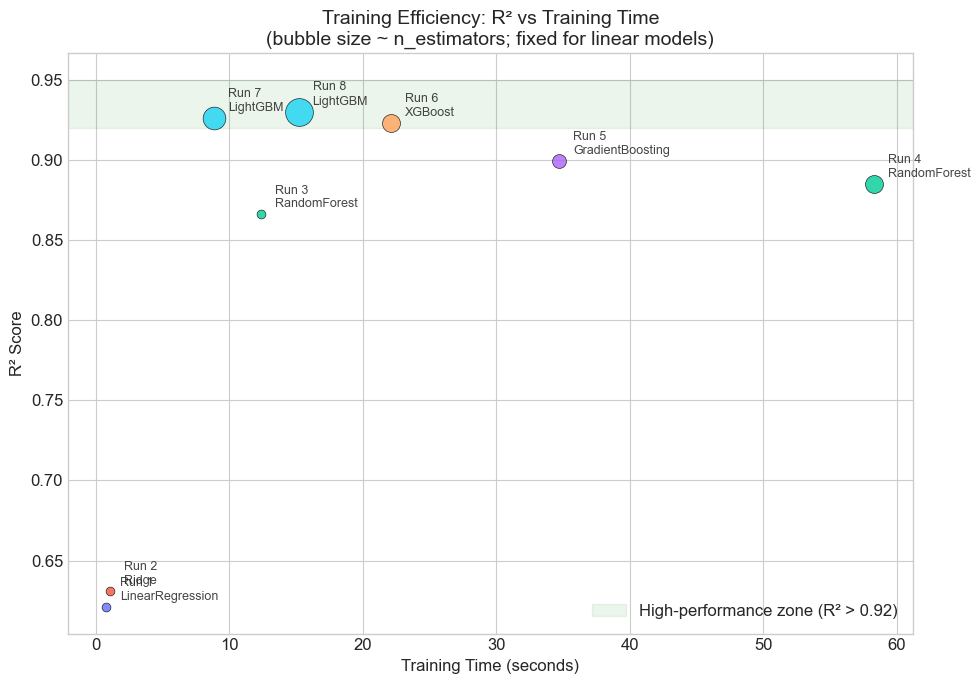

In [5]:
# Scatter plot: R\u00b2 vs Training Time
# Bubble size based on n_estimators (fixed size for linear models)
fig, ax = plt.subplots(figsize=(10, 7))

for _, row_data in df.iterrows():
    run = runs[int(row_data['Run']) - 1]  # Get original run data for params
    n_est = run['params'].get('n_estimators', None)
    bubble_size = (n_est / 3) if n_est else 40  # Scale estimators, fixed for linear
    bubble_size = max(bubble_size, 40)  # Minimum size

    color = MODEL_COLORS.get(row_data['Model'], '#999999')
    ax.scatter(
        row_data['Training Time (s)'],
        row_data['R\u00b2'],
        s=bubble_size,
        c=color,
        alpha=0.8,
        edgecolors='black',
        linewidth=0.5,
        zorder=5,
    )
    ax.annotate(
        f"Run {int(row_data['Run'])}\n{row_data['Model']}",
        (row_data['Training Time (s)'], row_data['R\u00b2']),
        textcoords='offset points',
        xytext=(10, 5),
        fontsize=9,
        alpha=0.85,
    )

ax.set_xlabel('Training Time (seconds)')
ax.set_ylabel('R\u00b2 Score')
ax.set_title('Training Efficiency: R\u00b2 vs Training Time\n(bubble size ~ n_estimators; fixed for linear models)')

# Highlight the "efficient frontier" region
ax.axhspan(0.92, 0.95, alpha=0.08, color='green', label='High-performance zone (R\u00b2 > 0.92)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

## Best vs Worst Analysis

In [6]:
# Best run (Run 8, LightGBM) vs Worst run (Run 1, LinearRegression)
best_run = runs[7]  # Run 8 (0-indexed)
worst_run = runs[0]  # Run 1 (0-indexed)

best_m = best_run['metrics']
worst_m = worst_run['metrics']

r2_improvement = ((best_m['r2'] - worst_m['r2']) / worst_m['r2']) * 100
mae_improvement = ((worst_m['mae'] - best_m['mae']) / worst_m['mae']) * 100
rmse_improvement = ((worst_m['rmse'] - best_m['rmse']) / worst_m['rmse']) * 100

print('=' * 65)
print('  BEST vs WORST RUN COMPARISON')
print('=' * 65)
print()
print(f"  {'Metric':<22} {'Worst (Run 1)':>14} {'Best (Run 8)':>14} {'Improvement':>14}")
print(f"  {'-'*22} {'-'*14} {'-'*14} {'-'*14}")
print(f"  {'Model':<22} {'LinearRegression':>14} {'LightGBM':>14} {'':>14}")
print(f"  {'R\u00b2':<22} {worst_m['r2']:>14.3f} {best_m['r2']:>14.3f} {r2_improvement:>+13.1f}%")
print(f"  {'MAE ($)':<22} {worst_m['mae']:>14,.2f} {best_m['mae']:>14,.2f} {mae_improvement:>+13.1f}%")
print(f"  {'RMSE ($)':<22} {worst_m['rmse']:>14,.2f} {best_m['rmse']:>14,.2f} {rmse_improvement:>+13.1f}%")
print(f"  {'Training Time (s)':<22} {worst_m['training_time_s']:>14.1f} {best_m['training_time_s']:>14.1f} {'':>14}")
print()
print(f"  Summary: The best model (LightGBM, Run 8) achieves a {r2_improvement:.1f}%")
print(f"  higher R\u00b2 and {mae_improvement:.1f}% lower MAE than the baseline.")
print('=' * 65)

  BEST vs WORST RUN COMPARISON

  Metric                  Worst (Run 1)   Best (Run 8)    Improvement
  ---------------------- -------------- -------------- --------------
  Model                  LinearRegression       LightGBM               
  R²                              0.621          0.930         +49.8%
  MAE ($)                      3,842.15       1,534.67         +60.1%
  RMSE ($)                     5,210.44       2,245.10         +56.9%
  Training Time (s)                 0.8           15.2               

  Summary: The best model (LightGBM, Run 8) achieves a 49.8%
  higher R² and 60.1% lower MAE than the baseline.


## Run Comparison: XGBoost vs LightGBM

In [7]:
# Side-by-side comparison: Run 6 (XGBoost) vs Run 7 (LightGBM)
run6 = runs[5]  # XGBoost (0-indexed)
run7 = runs[6]  # LightGBM (0-indexed)

# Metrics comparison
print('=' * 65)
print('  XGBoost (Run 6) vs LightGBM (Run 7)')
print('=' * 65)
print()
print('  --- Metrics ---')
print(f"  {'Metric':<22} {'XGBoost (Run 6)':>16} {'LightGBM (Run 7)':>18}")
print(f"  {'-'*22} {'-'*16} {'-'*18}")
m6 = run6['metrics']
m7 = run7['metrics']
print(f"  {'R\u00b2':<22} {m6['r2']:>16.3f} {m7['r2']:>18.3f}")
print(f"  {'MAE ($)':<22} {m6['mae']:>16,.2f} {m7['mae']:>18,.2f}")
print(f"  {'RMSE ($)':<22} {m6['rmse']:>16,.2f} {m7['rmse']:>18,.2f}")
print(f"  {'Training Time (s)':<22} {m6['training_time_s']:>16.1f} {m7['training_time_s']:>18.1f}")
print()

# Parameters comparison
print('  --- Hyperparameters ---')
all_param_keys = sorted(set(list(run6['params'].keys()) + list(run7['params'].keys())))
print(f"  {'Parameter':<22} {'XGBoost (Run 6)':>16} {'LightGBM (Run 7)':>18}")
print(f"  {'-'*22} {'-'*16} {'-'*18}")
for key in all_param_keys:
    v6 = run6['params'].get(key, '-')
    v7 = run7['params'].get(key, '-')
    print(f"  {key:<22} {str(v6):>16} {str(v7):>18}")

print()
speedup = m6['training_time_s'] / m7['training_time_s']
print(f"  LightGBM trains {speedup:.1f}x faster than XGBoost with comparable or better metrics.")
print('=' * 65)

  XGBoost (Run 6) vs LightGBM (Run 7)

  --- Metrics ---
  Metric                  XGBoost (Run 6)   LightGBM (Run 7)
  ---------------------- ---------------- ------------------
  R²                                0.923              0.926
  MAE ($)                        1,612.34           1,578.21
  RMSE ($)                       2,345.88           2,298.45
  Training Time (s)                  22.1                8.9

  --- Hyperparameters ---
  Parameter               XGBoost (Run 6)   LightGBM (Run 7)
  ---------------------- ---------------- ------------------
  colsample_bytree                    0.8                0.7
  learning_rate                      0.05               0.03
  max_depth                             6                 -1
  min_child_samples                     -                 20
  n_estimators                        500                800
  num_leaves                            -                 31
  reg_alpha                           0.1               0.05
 

## Recommendations

Based on the experiment progression:

1. **Linear models (Runs 1-2)** established a baseline with R\u00b2 ~ 0.62-0.63. These are fast but
   underfit the non-linear relationships in used car pricing.

2. **Random Forest (Runs 3-4)** provided a large jump to R\u00b2 ~ 0.87-0.89, demonstrating
   the importance of non-linear modeling. Feature engineering (one-hot encoding, mileage_per_year)
   contributed meaningfully.

3. **Gradient Boosting (Run 5)** slightly improved over tuned RF while being faster to train.

4. **XGBoost and LightGBM (Runs 6-8)** pushed into the R\u00b2 > 0.92 range. Log-transforming
   the price target and target encoding for brand were key feature engineering steps.

5. **LightGBM (Run 8)** is the recommended production model:
   - Best R\u00b2 (0.930) and lowest MAE ($1,535)
   - Reasonable training time (15.2s)
   - Lower learning rate with more trees provides stability

**Next steps:** Consider hyperparameter tuning with Optuna, stacking/blending top models,
and adding more features (e.g., car condition score, geographic pricing data).

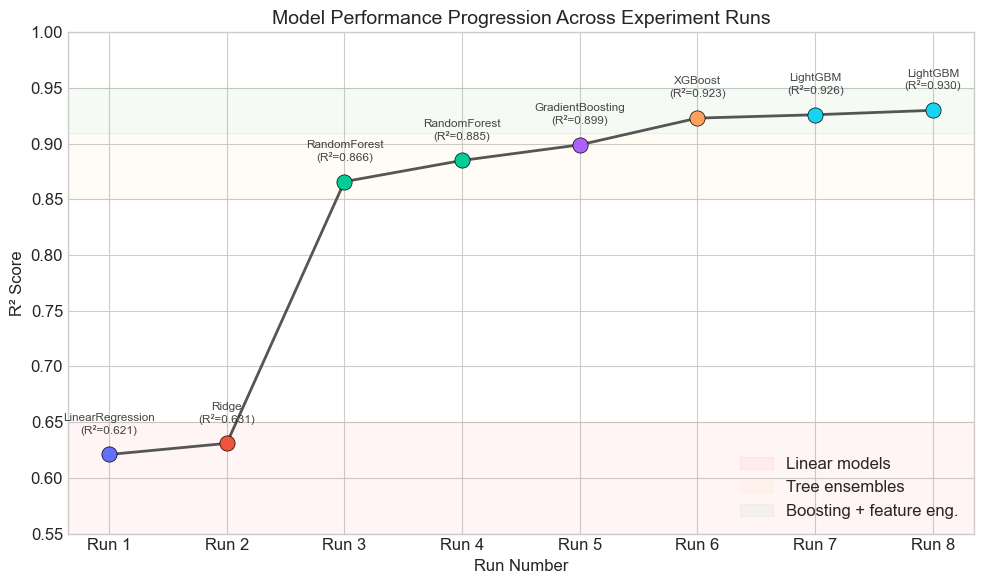


Total R² improvement from Run 1 to Run 8: 0.621 -> 0.930 (+49.8%)


In [8]:
# Learning curve: R\u00b2 improvement across runs
fig, ax = plt.subplots(figsize=(10, 6))

run_ids = df['Run'].values
r2_scores = df['R\u00b2'].values
models = df['Model'].values
colors = [MODEL_COLORS.get(m, '#999999') for m in models]

# Line
ax.plot(run_ids, r2_scores, 'o-', color='#555555', linewidth=2, markersize=0, zorder=3)

# Colored scatter points
for i, (x, y, c, m) in enumerate(zip(run_ids, r2_scores, colors, models)):
    ax.scatter(x, y, c=c, s=120, edgecolors='black', linewidth=0.5, zorder=5)
    ax.annotate(
        f'{m}\n(R\u00b2={y:.3f})',
        (x, y),
        textcoords='offset points',
        xytext=(0, 15),
        ha='center',
        fontsize=8.5,
        alpha=0.85,
    )

ax.set_xlabel('Run Number')
ax.set_ylabel('R\u00b2 Score')
ax.set_title('Model Performance Progression Across Experiment Runs')
ax.set_xticks(run_ids)
ax.set_xticklabels([f'Run {int(r)}' for r in run_ids])

# Shade improvement zones
ax.axhspan(0.0, 0.65, alpha=0.04, color='red', label='Linear models')
ax.axhspan(0.85, 0.91, alpha=0.04, color='orange', label='Tree ensembles')
ax.axhspan(0.91, 0.95, alpha=0.04, color='green', label='Boosting + feature eng.')

ax.set_ylim(0.55, 1.0)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

print(f"\nTotal R\u00b2 improvement from Run 1 to Run 8: {r2_scores[0]:.3f} -> {r2_scores[-1]:.3f} "
      f"(+{((r2_scores[-1] - r2_scores[0]) / r2_scores[0]) * 100:.1f}%)")